### Вводные данные

In [3]:
import pandas as pd
import numpy as np

# 1.1. Базовый прогноз СКР (Монте-Карло ансамбль без учета новой политики)
df_ensemble = pd.read_csv('nizh_forecast_ensemble.csv')

# 1.2. Эконометрические параметры (из модели PanelOLS)
# Влияние регионального материнского капитала на 3-го ребенка (rmc_3_lag1) на логарифм СКР
BETA_RMC_3 = 0.0185        # Точечная оценка коэффициента
SE_RMC_3 = 0.0047          # Стандартная ошибка (для генерации байесовского распределения)

# 1.3. Параметры региональной политики и демографическая структура
PAYOUT_AMOUNT = 1_080_000  # Размер выплаты РМК на 3-го ребенка в Нижегородской области (в рублях)

# 1.4. Макроэкономические параметры (Динамика доходов)
# Базовый среднедушевой денежный доход в Нижегородской области (рублей в месяц)
# Официальный прогноз с лагом
lagged_incomes_array = np.array([72_046, 75079, 80893, 87242, 93453])

# 1.5. Материнские капитал в размере СДД населения
rmc_coverage = PAYOUT_AMOUNT / lagged_incomes_array

### Генерация стохастических мультипликаторов (Сдвигов)

In [5]:
import stage3_funcs as my_funcs

my_funcs.set_seed(42) 

# Генерируем множители
policy_multipliers = my_funcs.generate_policy_multipliers(
    beta_mean=BETA_RMC_3,
    beta_se=SE_RMC_3,
    rmc_coverage=rmc_coverage,
    use_log_scaling=False
)

df_analysis = my_funcs.report_policy_impact(df_ensemble, policy_multipliers)

 АНАЛИЗ ЭФФЕКТА РМК НА ПРОГНОЗ СКР
Год 2026: 1.298 → 1.712 (+0.413; +31.84%)
Год 2027: 1.313 → 1.712 (+0.399; +30.37%)
Год 2028: 1.324 → 1.691 (+0.367; +27.91%)
Год 2029: 1.334 → 1.674 (+0.340; +25.64%)
Год 2030: 1.340 → 1.658 (+0.318; +23.75%)


На первом этапе эффект РМК рассматривался в линейной форме, что давало слишком сильный и слабо устойчивый к изменению базы прирост СКР.
Поэтому далее прирост по РМК был преобразован в логарифмическую форму, что позволило учесть эффект убывающей полезности от каждого последующего рубля.

### Генерация с логарифмической поправкой

In [8]:
# Генерируем множители
adj_policy_multipliers = my_funcs.generate_policy_multipliers(
    beta_mean=BETA_RMC_3,
    beta_se=SE_RMC_3,
    rmc_coverage=rmc_coverage,
    use_log_scaling=True
)

adj_df_analysis = my_funcs.report_policy_impact(df_ensemble, adj_policy_multipliers)

 АНАЛИЗ ЭФФЕКТА РМК НА ПРОГНОЗ СКР
Год 2026: 1.298 → 1.367 (+0.068; +5.27%)
Год 2027: 1.313 → 1.382 (+0.069; +5.20%)
Год 2028: 1.324 → 1.391 (+0.067; +5.06%)
Год 2029: 1.334 → 1.399 (+0.065; +4.93%)
Год 2030: 1.340 → 1.405 (+0.064; +4.80%)


Базовый прогноз указывает на устойчивый, но умеренный эффект РМК: региональный маткапитал обеспечивает дополнительный прирост СКР на 0.066 ребенка в 2026 году, который постепенно замедляется до 0.062 к 2030 году. Такая динамика отражает эффект "убывающей полезности" выплаты в условиях прогнозируемого роста доходов населения

### Визуализация распределний

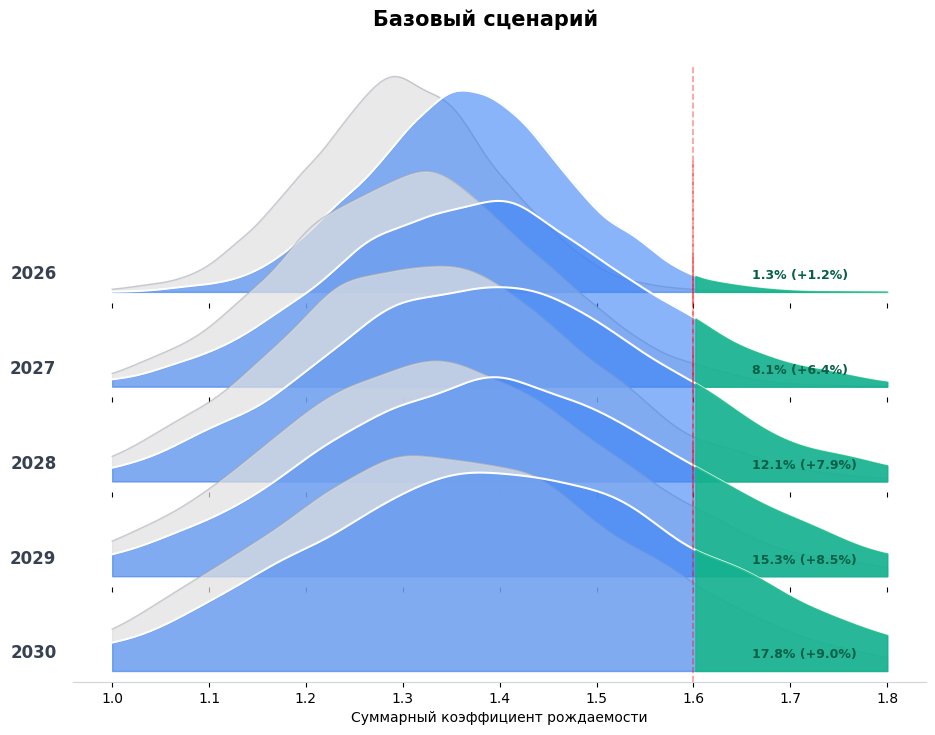

In [11]:
# Объявляем распределение со сдвигом на новую политику
policy_applied_ensemble = df_ensemble * adj_policy_multipliers

# Визуализируем распределения
my_funcs.plot_joyplot_with_delta(df_ensemble, policy_applied_ensemble, title='Базовый сценарий', target=1.6)

### Вариант индексирования РМК

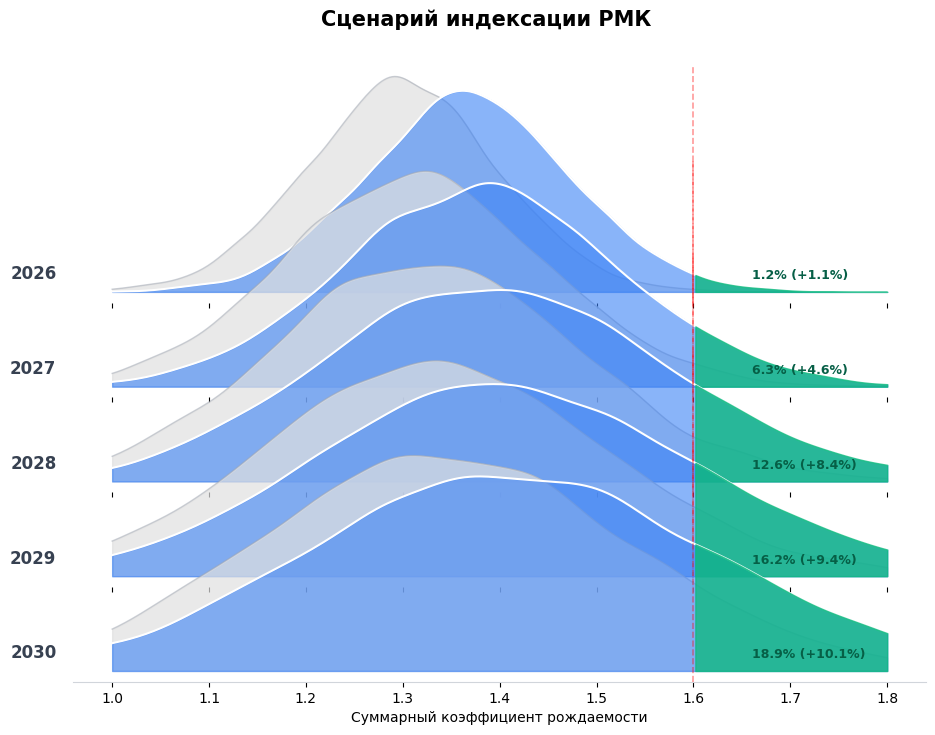

In [13]:
# 1. Считаем коэффициенты роста доходов (относительно первого прогнозного года)
# Это покажет, во сколько раз выросли доходы к каждому году
income_growth_factors = lagged_incomes_array / lagged_incomes_array[0]

# 2. Применяем индексацию к выплате
payout_indexed = PAYOUT_AMOUNT * income_growth_factors

# 3. Рассчитываем новое покрытие (оно будет стабильным, если индексация 1:1)
rmc_coverage_with_indexation = payout_indexed / lagged_incomes_array

# 4. Генерируем множители
indexed_policy_multipliers = my_funcs.generate_policy_multipliers(
    beta_mean=BETA_RMC_3,
    beta_se=SE_RMC_3,
    rmc_coverage=rmc_coverage_with_indexation,
    use_log_scaling=True
)

# 5. Объявляем распределение со сдвигом на новую политику
indexed_policy_ensemble = df_ensemble * indexed_policy_multipliers

# 6. Визуализируем распределения
my_funcs.plot_joyplot_with_delta(df_ensemble, indexed_policy_ensemble,  title='Сценарий индексации РМК', target=1.6)

### Вариант рефинансирования

Вариант, при котором перенаправляются выплаты на первых и вторых в третьего и более ребенка

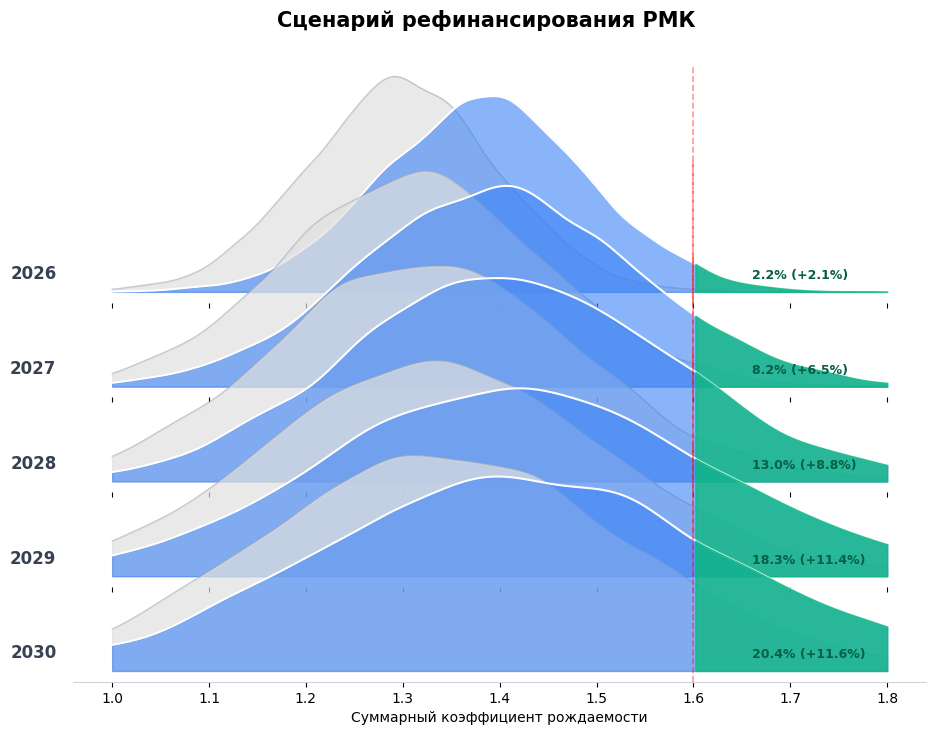

In [16]:
# Объявляем выплаты за первых детей
PAYOUT_FOR_FIRST = 360_000
PAYOUT_FOR_SECOND = 800_000

# Переводим все на третьих и более
payout_increased = PAYOUT_AMOUNT + PAYOUT_FOR_FIRST + PAYOUT_FOR_SECOND

# Создаем переменную рмк в сдд
rmc_coverage_with_big_payment = payout_increased / lagged_incomes_array

# Генерируем множители
increased_policy_multipliers = my_funcs.generate_policy_multipliers(
    beta_mean=BETA_RMC_3,
    beta_se=SE_RMC_3,
    rmc_coverage=rmc_coverage_with_big_payment,
    use_log_scaling=True
)

# Объявляем распределение со сдвигом на новую политику
increased_policy_ensemble = df_ensemble * increased_policy_multipliers

# Визуализируем распределения
my_funcs.plot_joyplot_with_delta(df_ensemble, increased_policy_ensemble,  title='Сценарий рефинансирования РМК', target=1.6)

### Выводы

Визуализация подтверждает гипотезу о положительном влиянии РМК на рождаемость. Наблюдается последовательное накопление плотности вероятности в диапазоне СКР > 1.4. Хотя вероятность достижения целевого показателя Минтруда (1.6) к 2030 году возрастает в 2 раза, для полной уверенности в достижении цели требуется комбинирование РМК с другими мерами демографической политики, так как даже полное перераспределение выплат в пользу третьего ребенка не способствует значимому приросту вероятности достижения цели в СКР равном 1.6